In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import pingouin as pg
from statsmodels.graphics.factorplots import interaction_plot
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.tools as tls
import plotly.express as px

FOLDER = Path("/home/slozgom/tfg_samuel/xperiments/experimentos_con_cnn")

experiment_variables = ["agent", "algorithm", "n_agents", "type", "network"]
agent_variables = [
    "minimum_loss_achieved",
    "maximum_accuracy_achieved",
    "maximum_recall_achieved",
    "maximum_precision_achieved",
    "maximum_f1_achieved",
    "mean_seconds_by_round",
]
network_variables = [
    "minimum_loss_net",
    "maximum_acc_net",
    "maximum_recall_net",
    "maximum_precision_net",
    "maximum_f1_net",
]
df = pd.DataFrame(columns=experiment_variables + agent_variables)


def max_network(data):
    df_numeric = pd.DataFrame(columns=network_variables)
    rounds = data.algorithm_round.unique()
    for r in rounds:
        round_data = data[(data.algorithm_round == r)]
        df_numeric.loc[len(df_numeric),] = list(
            map(
                lambda x: sum(x) / len(x),
                [
                    data.test_loss,
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
    return [min(df_numeric.best_loss_net)].extend(
        list(
            map(
                max,
                [
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
    )


# Modificar esta lista
experiments_list = [x for x in list(FOLDER.iterdir()) if "10" in x.name]
for PATH in experiments_list:
    dataset = pd.read_csv(PATH.joinpath("raw/nn_inference.csv"))
    agents = dataset.agent.unique()
    dataset = dataset[(dataset.algorithm_round <= 100)]
    descriptive = PATH.name.split("_")
    times = pd.read_csv(PATH.joinpath("raw/algorithm.csv"))
    times = times[(times.algorithm_round <= 100)]
    for ag in agents:
        agent_times = times[(times.agent == ag + "@localhost")]
        time = agent_times.seconds_to_complete.mean()

        data = dataset[(dataset.agent == ag)]
        numeric = list(
            map(
                max,
                [
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
        numerics = [data.test_loss.min()] + numeric + [time]
        row = [ag] + ["acol"] + descriptive + numerics
        df.loc[len(df)] = row

data = df[["type", "network", "minimum_loss_achieved"]]
data.groupby(["type", "network"])["minimum_loss_achieved"].agg(["mean", "std"])

mean       std
type network                     
iid  complete  1.427243  0.021001
     ring      1.429796  0.026407
     sw        1.430176  0.036894
non  complete  6.411328  2.498017
     ring      5.763233  2.103262
     sw        6.359513  2.677006

In [4]:
lista = []
for i, t in enumerate(data.type.unique()):
    for j, n in enumerate(data.network.unique()):
        p = data.minimum_loss_achieved[(data.type == t) & (data.network == n)]
        lista.append([t, n, p.mean()])

f = pd.DataFrame(lista, columns=["x", "trace", "response"])
f

,x,trace,response
0,non,complete,6.411328
1,non,sw,6.359513
2,non,ring,5.763233
3,iid,complete,1.427243
4,iid,sw,1.430176
5,iid,ring,1.429796


/home/slozgom/tfg_samuel/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning:

10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



<Axes: xlabel='type', ylabel='minimum_loss_achieved'>

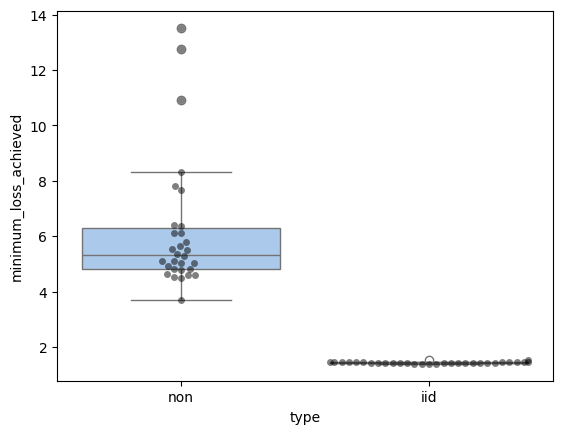

In [5]:

sns.boxplot(x="type", y="minimum_loss_achieved", data=data, hue="type", palette="pastel")
sns.swarmplot(x="type", y="minimum_loss_achieved", data=data, color='black',
    alpha = 0.5)

In [ ]:
fig = make_subplots(
    rows=3,
    cols=1,
)
fig3 = px.box(
    data,
    x="type",
    y="minimum_loss_achieved",
    color="type",
    points="all",
    template="seaborn",
)
fig4 = px.box(
    data,
    x="network",
    y="minimum_loss_achieved",
    color="network",
    points="all",
    template="seaborn",
)

for i, x_fig in enumerate([fig3, fig4, fig3]):
    x_traces = []
    for trace in range(len(x_fig["data"])):
        t = x_fig["data"][trace]
        t.showlegend = 0 == i
        x_traces.append(t)
    for traces in x_traces:
        fig.append_trace(traces, row=i + 1, col=1)

fig.update_layout(height=1000, width=900)

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig3 = px.box(
    data,
    x="type",
    y="minimum_loss_achieved",
    color="type",
    #points="all",
    template="seaborn",
)

fig = go.Figure(data = [fig3.data, fig4.data], )
fig

In [38]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv("/home/slozgom/tfg_samuel/nacio/nn_train.csv")
df = df[df.epoch == 1].copy()

agents = sorted(df["agent"].unique())

fig = go.Figure()

# Add all traces initially
for agent in agents:
    df_agent = df[df["agent"] == agent]
    df_x = df_agent["algorithm_round"]
    df_y = df_agent["accuracy"]
    fig.add_trace(
        go.Scatter(
            x=df_x,
            y=df_y,
            mode="lines+markers",
            name=agent,  # nombre leyenda
            visible=True,  # Start with all traces visible
        )
    )

In [ ]:
go.Table(
    header=dict(values=list(data.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[data.get(col).to_list() for col in data.columns.to_list()],
               fill_color='lavender',
               align='left'))

In [ ]:
from dash import html

a = html.Div([
    html.H1('Hello Dash'),
    html.Div([
        html.P('Dash converts Python classes into HTML'),
        html.P("This conversion happens behind the scenes by Dash's JavaScript front-end")
    ])
])

a.

{'props': {'children': [H1('Hello Dash'),
   Div([P('Dash converts Python classes into HTML'), P("This conversion happens behind the scenes by Dash's JavaScript front-end")])]},
 'type': 'Div',
 'namespace': 'dash_html_components'}